In [ ]:
import os, sys
# Run from project root so all relative paths and imports work
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [1]:
import os, json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from models.detection_transformer import DASCountTransformer
from dataset import DASCountDataset, IDX_TO_TYPE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/chao/miniconda3/envs/au_sable/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Using device: cuda


In [2]:
DATA_DIR = "data"
SAVE_DIR = "results/detection"

df = pd.read_csv(os.path.join(DATA_DIR, "corrected_labels.csv"))
df["data_path"] = df["sample_id"].apply(
    lambda x: f"{DATA_DIR}/denoised/denoised_sample_{str(x).zfill(6)}.npy"
)

with open(os.path.join(SAVE_DIR, "splits.json")) as f:
    splits = json.load(f)

test_df = df[df["sample_id"].isin(splits["test"])].reset_index(drop=True)
print(f"Test set: {len(test_df)} samples")
display(test_df[["sample_id", "count", "vehicle_type"]])

Test set: 18 samples


,sample_id,count,vehicle_type
0,2,3,mixed
1,10,1,suv
2,20,1,suv
3,28,2,mixed
4,36,0,background
5,55,4,mixed
6,57,3,mixed
7,60,1,sedan
8,76,3,mixed
9,77,4,mixed


In [3]:
test_ds  = DASCountDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)
print(f"Test samples: {len(test_ds)}")

Test samples: 18


In [4]:
sample_x, _, _ = test_ds[0]
num_spatial_channels = sample_x.shape[1]
print(f"Detected {num_spatial_channels} spatial channels.")

model = DASCountTransformer(
    spatial_channels=num_spatial_channels,
    d_model=64,
    nhead=4,
    num_layers=2,
).to(device)

Detected 34 spatial channels.


In [5]:
# Load the trained model saved by: python train.py --task detection
model.load_state_dict(torch.load("results/detection/best_model.pt", map_location=device))
model.eval()
print("Model loaded from results/detection/best_model.pt")

Model loaded from results/detection/best_model.pt


/tmp/ipykernel_2667993/4094462890.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("results/detection/best_model.pt", map_location=device

In [6]:
# --- Replace Cell 6 ---
# ---------------------------------------------------------
# Cell 6: Evaluation with Advanced Counting Metrics & Logic
# ---------------------------------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

# Reverse mapping to turn integers back to strings
IDX_TO_TYPE = {0: 'background', 1: 'mixed', 2: 'suv', 3: 'van', 4: 'sedan', 5: 'truck'}

def enforce_business_logic(raw_count_pred, type_logits):
    """Enforces rules: count=0 -> background, count>1 -> mixed, count=1 -> (suv|van|sedan|truck)"""
    final_count = int(round(raw_count_pred))
    
    if final_count == 0:
        final_type = 'background'
    elif final_count > 1:
        final_type = 'mixed'
    else: # final_count == 1
        # Extract logits only for indices 2, 3, 4, 5
        single_vehicle_logits = type_logits[2:6]
        # Find local max index (0 to 3) and add 2 to match original indices
        best_single_idx = np.argmax(single_vehicle_logits) + 2
        final_type = IDX_TO_TYPE[best_single_idx]
        
    return final_count, final_type

model.eval()
actual_counts, pred_counts = [], []
actual_types, pred_types = [], []

with torch.no_grad():
    for x, y_count, y_type in test_loader:
        x = x.to(device)
        p_counts, p_types = model(x)
        
        # Move to CPU for processing
        p_counts = p_counts.cpu().numpy().flatten()
        p_types = p_types.cpu().numpy()
        y_count = y_count.numpy().flatten()
        y_type = y_type.numpy().flatten()
        
        for i in range(len(x)):
            actual_counts.append(y_count[i])
            actual_types.append(IDX_TO_TYPE[y_type[i]])
            
            # Apply our strict rules!
            final_c, final_t = enforce_business_logic(p_counts[i], p_types[i])
            pred_counts.append(final_c)
            pred_types.append(final_t)

print("--- Test Set Predictions ---")
for act_c, act_t, pred_c, pred_t in zip(actual_counts, actual_types, pred_counts, pred_types):
    print(f"Actual: {int(act_c)} ({act_t:10s}) | Predicted: {pred_c} ({pred_t})")

# --- Calculate Metrics ---
actuals_arr = np.array(actual_counts)
preds_arr = np.array(pred_counts)

exact_acc = np.mean(actuals_arr == preds_arr) * 100
off_by_one_acc = np.mean(np.abs(actuals_arr - preds_arr) <= 1) * 100
mae = mean_absolute_error(actuals_arr, preds_arr)
rmse = np.sqrt(mean_squared_error(actuals_arr, preds_arr))
bias = np.mean(preds_arr - actuals_arr)

# Type classification accuracy
type_acc = accuracy_score(actual_types, pred_types) * 100

print("\n--- Final Metrics ---")
print(f"Vehicle Type Accuracy: {type_acc:.1f}%")
print(f"Count Exact Match:     {exact_acc:.1f}%")
print(f"Count Off-by-One:      {off_by_one_acc:.1f}%")
print(f"Count MAE:             {mae:.2f} events")
print(f"Count RMSE:            {rmse:.2f} events")
print(f"Count Bias:            {bias:.2f}")

--- Test Set Predictions ---
Actual: 3 (mixed     ) | Predicted: 2 (mixed)
Actual: 1 (suv       ) | Predicted: 1 (suv)
Actual: 1 (suv       ) | Predicted: 1 (suv)
Actual: 2 (mixed     ) | Predicted: 3 (mixed)
Actual: 0 (background) | Predicted: 0 (background)
Actual: 4 (mixed     ) | Predicted: 3 (mixed)
Actual: 3 (mixed     ) | Predicted: 3 (mixed)
Actual: 1 (sedan     ) | Predicted: 1 (suv)
Actual: 3 (mixed     ) | Predicted: 3 (mixed)
Actual: 4 (mixed     ) | Predicted: 3 (mixed)
Actual: 1 (suv       ) | Predicted: 1 (truck)
Actual: 0 (background) | Predicted: 0 (background)
Actual: 0 (background) | Predicted: 0 (background)
Actual: 0 (background) | Predicted: 0 (background)
Actual: 0 (background) | Predicted: 0 (background)
Actual: 0 (background) | Predicted: 0 (background)
Actual: 0 (background) | Predicted: 0 (background)
Actual: 2 (mixed     ) | Predicted: 1 (truck)

--- Final Metrics ---
Vehicle Type Accuracy: 83.3%
Count Exact Match:     72.2%
Count Off-by-One:      100.0%
Cou

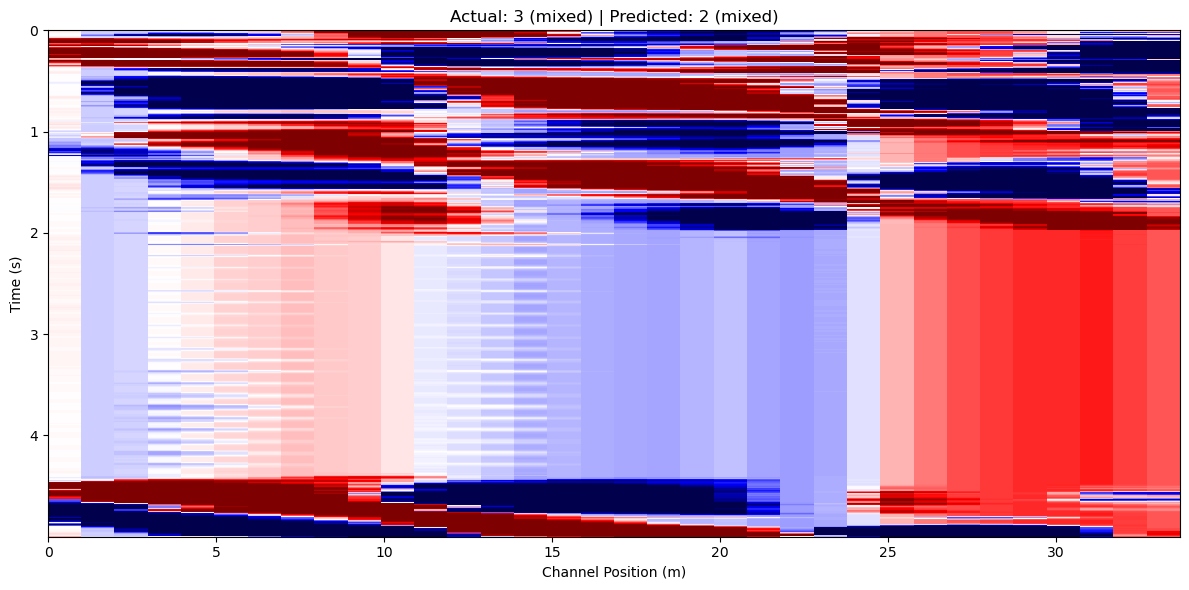

In [7]:
from Utilities import plot_das_data
from config import DAS_FILE
from DAS import DAS
import matplotlib.pyplot as plt

das = DAS(DAS_FILE)
dx = das.meta['dx']
dt = das.meta['dt']

SAMPLE_IDX = 0  # change to inspect different test samples

x_tensor, y_count_tensor, y_type_tensor = test_ds[SAMPLE_IDX]
with torch.no_grad():
    raw_count_tensor, type_logits_tensor = model(x_tensor.unsqueeze(0).to(device))

raw_count = raw_count_tensor.item()
type_logits = type_logits_tensor.cpu().numpy().flatten()
pred_count, pred_type = enforce_business_logic(raw_count, type_logits)

actual_count = int(y_count_tensor.item())
actual_type = IDX_TO_TYPE[int(y_type_tensor.item())]

plot_data = x_tensor.squeeze().numpy()
fig, ax = plt.subplots(figsize=(12, 6))
plot_das_data(data=plot_data, channels=np.arange(plot_data.shape[0]), dx=dx, dt=dt,
              title=f"Actual: {actual_count} ({actual_type}) | Predicted: {pred_count} ({pred_type})",
              ax=ax, fig=fig, show=False)
plt.tight_layout()
plt.show()